# Task 2 — EvoMine: Mining Graph Evolution Rules in Temporal Networks

**Author:** Carlo Invernizzi  
**Topic:** Multilevel evolutionary profiles of complex networks through temporal network motifs  
**Tool:** EvoMine / GERANIO toolkit  

---

## Overview

This notebook applies **EvoMine** (part of the GERANIO toolkit) to the same two datasets used in Task 1:
- `ia-facebook-wall-wosn-dir` (Facebook Wall interactions)
- `CollegeMsg` (SNAP College private messages)

EvoMine mines **Graph Evolution Rules (GERs)**: interpretable patterns that describe how a small subgraph (precondition) transforms into a larger one (postcondition) as new edges are added over time. This is fundamentally different from Task 1's MTM/TMC approach, which counts static temporal motifs.

### Architecture note
The EvoMine and GERM binaries in `EvoMine/algorithms/` are **Linux x86-64 ELF executables** and will not run natively on macOS ARM64 (Apple Silicon). This notebook:
1. Converts datasets to GER input format
2. Demonstrates how to call EvoMine (command structure)
3. Parses and visualizes the **pre-computed output** for the DBLP dataset that ships with the repo
4. Provides a workaround path (Docker/Linux VM) for running on new datasets

**Pipeline:** Raw data → GER format → EvoMine binary → Output rules → Parse → Visualize profiles

---
## 1. Imports and Setup

In [2]:
import os
import sys
import pickle
import platform
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Configure matplotlib
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

print(f"Python {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Machine arch: {platform.machine()}")
print(f"NetworkX version: {nx.__version__}")

Python 3.9.6 (default, Jan  9 2026, 11:03:41) 
[Clang 17.0.0 (clang-1700.6.4.2)]
Platform: macOS-26.3.1-arm64-arm-64bit
Machine arch: arm64
NetworkX version: 3.2.1


In [3]:
# --- Directory paths (absolute, robust to cwd) ---
TASK2_DIR    = Path('/Users/inve14/Desktop/UnInve/Tirocinio/lab/task_2')
EVOMINE_DIR  = TASK2_DIR / 'EvoMine'
INPUT_DIR    = EVOMINE_DIR / 'input-files'
OUTPUT_DIR   = EVOMINE_DIR / 'output-files'
RAW_DIR      = EVOMINE_DIR / 'raw-datasets'
OUT_PNG      = TASK2_DIR / 'output_png'
OUT_DATA     = TASK2_DIR / 'output_data'

# Dataset paths (from Task 1)
FACEBOOK_PATH = Path('/Users/inve14/Desktop/UnInve/Tirocinio/lab/task_1/task_1_facebook/ia-facebook-wall-wosn-dir.edges')
COLLEGE_PATH  = Path('/Users/inve14/Desktop/UnInve/Tirocinio/lab/task_1/task_1_SNAP/CollegeMsg.txt')

# Ensure output directories exist
OUT_PNG.mkdir(parents=True, exist_ok=True)
OUT_DATA.mkdir(parents=True, exist_ok=True)
(TASK2_DIR / 'EvoMine' / 'processed-outputs').mkdir(parents=True, exist_ok=True)

print("EvoMine dir:", EVOMINE_DIR)
print("Input dir:", INPUT_DIR)
print("Output dir:", OUTPUT_DIR)
print("Output png:", OUT_PNG)
print("Output data:", OUT_DATA)

EvoMine dir: /Users/inve14/Desktop/UnInve/Tirocinio/lab/task_2/EvoMine
Input dir: /Users/inve14/Desktop/UnInve/Tirocinio/lab/task_2/EvoMine/input-files
Output dir: /Users/inve14/Desktop/UnInve/Tirocinio/lab/task_2/EvoMine/output-files
Output png: /Users/inve14/Desktop/UnInve/Tirocinio/lab/task_2/output_png
Output data: /Users/inve14/Desktop/UnInve/Tirocinio/lab/task_2/output_data


In [4]:
# Add EvoMine directory to path so we can import its modules
sys.path.insert(0, str(EVOMINE_DIR))

import file_converters as f
import running_algorithms as r
import general_mapping as gm
import analysis as a
import drawing as d

print("GERANIO modules imported successfully")

GERANIO modules imported successfully


---
## 2. Binary Compatibility Check

The EvoMine and GERM binaries are Linux x86-64 ELF executables. We detect whether they can run on the current platform.

In [5]:
import subprocess

evomine_bin = EVOMINE_DIR / 'algorithms' / 'evomine'
germ_bin    = EVOMINE_DIR / 'algorithms' / 'germ'

# Make executables
os.chmod(evomine_bin, 0o755)
os.chmod(germ_bin,    0o755)

def check_binary(bin_path):
    """Try to run binary, return True if it executes (even if it errors on args)."""
    try:
        result = subprocess.run([str(bin_path), '--help'],
                                capture_output=True, timeout=5)
        return True, result.returncode
    except (OSError, subprocess.TimeoutExpired) as e:
        return False, str(e)

evomine_ok, evomine_rc = check_binary(evomine_bin)
germ_ok, germ_rc       = check_binary(germ_bin)

print(f"EvoMine binary executable: {evomine_ok}  (return code: {evomine_rc})")
print(f"GERM binary executable:    {germ_ok}  (return code: {germ_rc})")

BINARIES_AVAILABLE = evomine_ok

if not BINARIES_AVAILABLE:
    print()
    print("WARNING: Binaries are Linux x86-64 ELF and cannot run on macOS ARM64.")
    print("To run EvoMine on this machine:")
    print("  Option A — Docker:  docker run --rm -v $(pwd):/data ubuntu:22.04 ./algorithms/evomine ...")
    print("  Option B — Linux VM or remote server with x86-64 Linux")
    print("  Option C — Rosetta 2 + Linux binary (experimental)")
    print()
    print("This notebook will use the pre-computed DBLP output for analysis/visualization.")
else:
    print("Binaries are available. EvoMine can be run directly.")

EvoMine binary executable: False  (return code: [Errno 8] Exec format error: '/Users/inve14/Desktop/UnInve/Tirocinio/lab/task_2/EvoMine/algorithms/evomine')
GERM binary executable:    False  (return code: [Errno 8] Exec format error: '/Users/inve14/Desktop/UnInve/Tirocinio/lab/task_2/EvoMine/algorithms/germ')

To run EvoMine on this machine:
  Option A — Docker:  docker run --rm -v $(pwd):/data ubuntu:22.04 ./algorithms/evomine ...
  Option B — Linux VM or remote server with x86-64 Linux
  Option C — Rosetta 2 + Linux binary (experimental)

This notebook will use the pre-computed DBLP output for analysis/visualization.


---
## 3. Dataset Exploration

We use the same two datasets as Task 1. Let us explore their format before converting.

In [6]:
def load_edges_raw(path, sep=None, skip_comment='%', skip_self_loops=True, max_cols=3):
    """Load a temporal edge list, returning list of (src, dst, timestamp) tuples."""
    edges = []
    with open(path, 'r') as fh:
        for line in fh:
            line = line.strip()
            if not line or line.startswith(skip_comment):
                continue
            parts = line.split(sep)[:max_cols]
            if len(parts) < 3:
                continue
            try:
                src, dst, ts = int(parts[0]), int(parts[1]), int(parts[-1])
            except ValueError:
                continue
            if skip_self_loops and src == dst:
                continue
            edges.append((src, dst, ts))
    return edges

# CollegeMsg: columns are  src  dst  timestamp  (space separated, no header)
college_edges = load_edges_raw(COLLEGE_PATH)
college_df    = pd.DataFrame(college_edges, columns=['src', 'dst', 'ts'])

# Facebook Wall: columns are  src  dst  weight  timestamp  (tab/space mixed, % comment header)
# We use the last column as timestamp
facebook_edges = load_edges_raw(FACEBOOK_PATH, skip_comment='%', max_cols=4)
facebook_df    = pd.DataFrame(facebook_edges, columns=['src', 'dst', 'ts'])

print("=== CollegeMsg ===")
print(f"  Edges: {len(college_df):,}")
print(f"  Unique nodes: {len(set(college_df.src) | set(college_df.dst)):,}")
print(f"  Time range: {college_df.ts.min()} — {college_df.ts.max()}")
print(f"  Span (days): {(college_df.ts.max() - college_df.ts.min()) / 86400:.1f}")
print()
print("=== Facebook Wall ===")
print(f"  Edges: {len(facebook_df):,}")
print(f"  Unique nodes: {len(set(facebook_df.src) | set(facebook_df.dst)):,}")
print(f"  Time range: {facebook_df.ts.min()} — {facebook_df.ts.max()}")
print(f"  Span (days): {(facebook_df.ts.max() - facebook_df.ts.min()) / 86400:.1f}")

=== CollegeMsg ===
  Edges: 59,835
  Unique nodes: 1,899
  Time range: 1082040961 — 1098777142
  Span (days): 193.7

=== Facebook Wall ===
  Edges: 855,542
  Unique nodes: 45,813
  Time range: 1097725406 — 1232598691
  Span (days): 1561.0


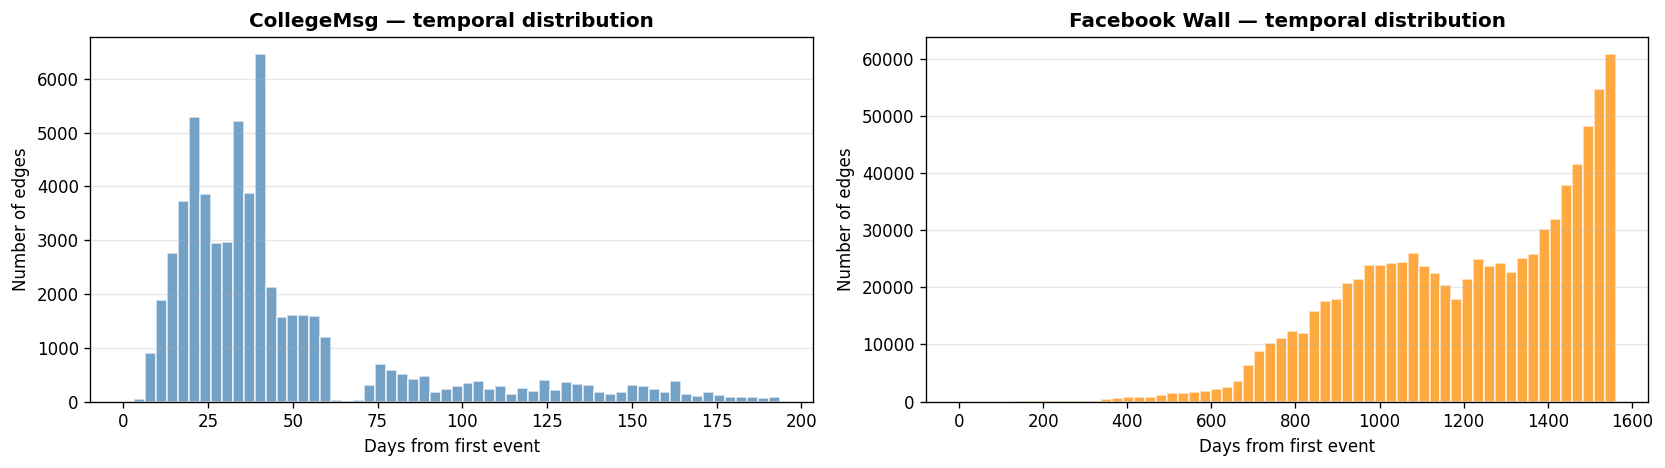

Saved to /Users/inve14/Desktop/UnInve/Tirocinio/lab/task_2/output_png/temporal_dist_both.png


In [7]:
# Temporal activity distribution for both datasets
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, df, label, color in zip(
        axes,
        [college_df, facebook_df],
        ['CollegeMsg', 'Facebook Wall'],
        ['steelblue', 'darkorange']):

    # Convert epoch seconds to days from start
    days = (df['ts'] - df['ts'].min()) / 86400
    ax.hist(days, bins=60, color=color, alpha=0.75, edgecolor='white')
    ax.set_title(f'{label} — temporal distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Days from first event', fontsize=10)
    ax.set_ylabel('Number of edges', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_PNG / 'temporal_dist_both.png', bbox_inches='tight')
plt.show()
print("Saved to", OUT_PNG / 'temporal_dist_both.png')

---
## 4. Dataset Conversion to GER Format

EvoMine (and GERM) require a specific input format:
```
t # 0
v <node_id> <node_label>
...
e <src> <dst> <timestamp_bucket>
...
```
- `t # 0` marks the graph (only one graph per file for temporal data).
- `v` lines declare all nodes, each with a label (usually `0`).
- `e` lines list all directed edges sorted by timestamp. The timestamp is discretised into integer buckets.

The GERANIO `file_converters` module handles this conversion automatically, but it requires integer node IDs starting from 0 and contiguous.

**Important**: Facebook Wall is very large (~877k edges). We use a sample for conversion.

In [8]:
def edges_to_ger_format(edges, output_path):
    """
    Convert a list of (src, dst, ts) tuples to GER input format.
    Remaps node IDs to 0..N-1, sorts by timestamp, writes the file.
    
    Parameters
    ----------
    edges       : list of (src, dst, ts)
    output_path : str or Path — destination file path
    """
    # Sort by timestamp
    edges = sorted(edges, key=lambda x: x[2])

    # Remap node IDs to contiguous integers starting from 0
    all_nodes = sorted(set(n for e in edges for n in e[:2]))
    node_map  = {n: i for i, n in enumerate(all_nodes)}

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    with open(output_path, 'w') as fh:
        fh.write('t # 0\n')
        for n in all_nodes:
            fh.write(f'v {node_map[n]} 0\n')
        for src, dst, ts in edges:
            fh.write(f'e {node_map[src]} {node_map[dst]} {ts}\n')

    print(f"Written {len(all_nodes):,} nodes and {len(edges):,} edges to {output_path}")


def sample_and_convert(edges_df, n_edges, output_path, seed=42):
    """
    Take the first n_edges rows (by timestamp order) and convert.
    Using the earliest edges keeps a connected temporal subgraph.
    """
    sample_df = edges_df.sort_values('ts').head(n_edges)
    edges = list(zip(sample_df.src, sample_df.dst, sample_df.ts))
    edges_to_ger_format(edges, output_path)
    return edges

In [9]:
# --- CollegeMsg: use full dataset (59,835 edges) ---
COLLEGE_GER = EVOMINE_DIR / 'input-files' / 'collegemsg_ger.txt'
college_ger_edges = sample_and_convert(college_df, len(college_df), COLLEGE_GER)

Written 1,899 nodes and 59,835 edges to /Users/inve14/Desktop/UnInve/Tirocinio/lab/task_2/EvoMine/input-files/collegemsg_ger.txt


In [10]:
# --- Facebook Wall: use first 10,000 edges (the full 877k is too large for a quick run) ---
FACEBOOK_GER = EVOMINE_DIR / 'input-files' / 'facebook_ger.txt'
facebook_ger_edges = sample_and_convert(facebook_df, 10_000, FACEBOOK_GER)

Written 3,757 nodes and 10,000 edges to /Users/inve14/Desktop/UnInve/Tirocinio/lab/task_2/EvoMine/input-files/facebook_ger.txt


In [11]:
# Verify the GER files look correct
for path in [COLLEGE_GER, FACEBOOK_GER]:
    with open(path) as fh:
        first_lines = [next(fh) for _ in range(8)]
    print(f"=== {path.name} (first 8 lines) ===")
    for line in first_lines:
        print(' ', line, end='')
    print()

=== collegemsg_ger.txt (first 8 lines) ===
  t # 0
  v 0 0
  v 1 0
  v 2 0
  v 3 0
  v 4 0
  v 5 0
  v 6 0

=== facebook_ger.txt (first 8 lines) ===
  t # 0
  v 0 0
  v 1 0
  v 2 0
  v 3 0
  v 4 0
  v 5 0
  v 6 0



---
## 5. Running EvoMine

### Command structure
```bash
cd EvoMine/
./algorithms/evomine -s <support> -e <max_edges> -T <projection> -t -d/-u -f <input_file>
```

### Key parameters
| Parameter | Values | Description |
|-----------|--------|-------------|
| `-s` | integer | Minimum support (frequency threshold). e.g. `1000` for CollegeMsg, `5000` for large graphs |
| `-e` | 2, 3, 4 | Max number of edges in the **postcondition** (head of the rule) |
| `-T` | `full`, `neigh`, `event` | Support type: `full`/`neigh` = MIB support; `event` = event-based |
| `-d` | flag | Directed graph mode |
| `-u` | flag | Undirected graph mode |
| `-r` | flag | Include edge **removal** events (not just insertions) |
| `-c` | flag | Edge-labeled graph |
| `-C` | flag | Node-labeled graph |
| `-t` | flag | Temporal mode (required for temporal graphs) |
| `-f` | path | Input file in GER format |

### Output file naming
EvoMine saves output as: `<input_filename>.out.evomine.<PROJECTION>.<support>.<max_edges>`

### Example commands for our datasets
```bash
# From EvoMine/ directory:

# CollegeMsg — directed, support=1000, max 3 edges in postcondition
./algorithms/evomine -s 1000 -e 3 -T full -t -d -f ./input-files/collegemsg_ger.txt

# Facebook Wall sample — directed, support=500, max 3 edges
./algorithms/evomine -s 500 -e 3 -T full -t -d -f ./input-files/facebook_ger.txt

# GERM on same data (undirected)
./algorithms/germ 5000 ./input-files/collegemsg_ger.txt 3
```

In [12]:
# Run EvoMine only if binaries are available
os.chdir(EVOMINE_DIR)  # EvoMine must be run from its directory

if BINARIES_AVAILABLE:
    # CollegeMsg — directed graph, support=1000, max 3 edges in postcondition
    r.run_algorithm(
        algo       = 'EvoMine',
        sup        = 1000,
        maxedge    = 3,
        filename   = str(COLLEGE_GER),
        outputfile = str(OUT_DATA / 'college_evomine_1000_3.txt'),
        directed   = True,
        projection = 'full',
        verbose    = True,
        superverbose = False
    )

    # Facebook Wall sample — directed, support=500
    r.run_algorithm(
        algo       = 'EvoMine',
        sup        = 500,
        maxedge    = 3,
        filename   = str(FACEBOOK_GER),
        outputfile = str(OUT_DATA / 'facebook_evomine_500_3.txt'),
        directed   = True,
        projection = 'full',
        verbose    = True,
        superverbose = False
    )
else:
    print("Binaries not available on this platform (macOS ARM64 vs Linux x86-64).")
    print("Skipping EvoMine execution. Using pre-computed DBLP output for analysis.")
    print()
    print("To run on Linux/Docker:")
    print("  cd EvoMine/")
    print("  ./algorithms/evomine -s 1000 -e 3 -T full -t -d -f ./input-files/collegemsg_ger.txt")
    print("  ./algorithms/evomine -s 500  -e 3 -T full -t -d -f ./input-files/facebook_ger.txt")

Binaries not available on this platform (macOS ARM64 vs Linux x86-64).
Skipping EvoMine execution. Using pre-computed DBLP output for analysis.

To run on Linux/Docker:
  cd EvoMine/
  ./algorithms/evomine -s 1000 -e 3 -T full -t -d -f ./input-files/collegemsg_ger.txt
  ./algorithms/evomine -s 500  -e 3 -T full -t -d -f ./input-files/facebook_ger.txt


---
## 6. Analysis Using Pre-computed Output (DBLP 2003-2005)

The GERANIO repository ships with a pre-computed GERM output for the DBLP co-authorship dataset (2003-2005). We use this to demonstrate the full analysis pipeline.

The output file format is:
```
t # <pattern_id> <support>
v <node_id> <node_label>
...
e <src> <dst> <timestamp_bucket>   # 0 = precondition, 1/2/3 = postcondition
```
Each block starting with `t #` defines one GER. Edges with timestamp `0` form the **precondition** (body); edges with higher timestamps form the **postcondition** (head).

In [13]:
DBLP_OUTPUT = EVOMINE_DIR / 'output-files' / 'dblp0305.5000.3.txt'

info_list, patterns, support_patterns, mapping = f.from_ger_output(str(DBLP_OUTPUT))
pattern_list, support = f.obtain_pattern_list(patterns, support_patterns, algorithm='germ')

print(f"Total patterns found: {len(patterns)}")
print(f"Pattern IDs: {list(patterns.keys())}")
print()

# Show first 3 patterns
for pid in list(patterns.keys())[:3]:
    p = patterns[pid]
    print(f"Pattern {pid} | support={p['support']}")
    print(f"  Nodes: {p['nodes']}")
    print(f"  Edges: {p['edges']}  (t=0 → precondition, t>0 → postcondition)")
    print()

Total patterns found: 20
Pattern IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

Pattern 0 | support=109044
  Nodes: [0, 1]
  Edges: [(0, 1, 0)]  (t=0 → precondition, t>0 → postcondition)

Pattern 1 | support=83197
  Nodes: [0, 1, 2]
  Edges: [(0, 1, 0), (1, 2, 0)]  (t=0 → precondition, t>0 → postcondition)

Pattern 2 | support=76462
  Nodes: [0, 1, 2]
  Edges: [(0, 1, 0), (0, 2, 0), (1, 2, 0)]  (t=0 → precondition, t>0 → postcondition)



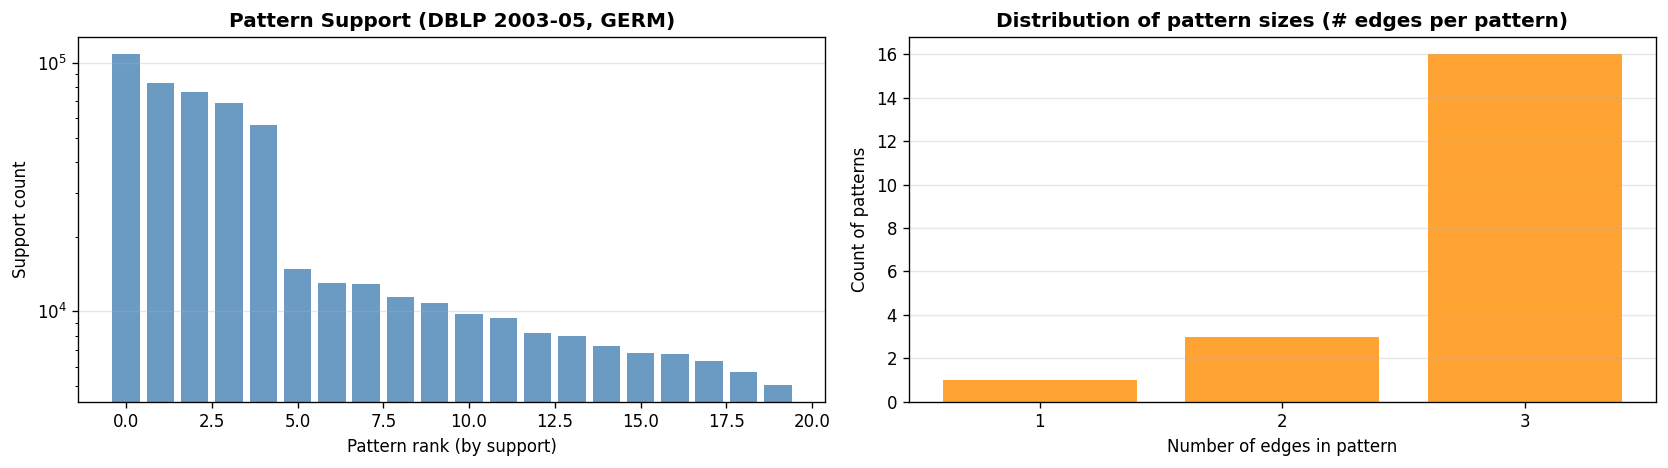

In [14]:
# Support distribution
supports = [int(v) for v in support_patterns.values()]
ids_sorted = sorted(range(len(supports)), key=lambda i: supports[i], reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart of support values (sorted)
ax = axes[0]
ax.bar(range(len(supports)), [supports[i] for i in ids_sorted], color='steelblue', alpha=0.8)
ax.set_title('Pattern Support (DBLP 2003-05, GERM)', fontsize=12, fontweight='bold')
ax.set_xlabel('Pattern rank (by support)', fontsize=10)
ax.set_ylabel('Support count', fontsize=10)
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3)

# Edge count distribution
ax = axes[1]
edge_counts = [len(patterns[pid]['edges']) for pid in patterns]
edge_count_dist = Counter(edge_counts)
ax.bar(edge_count_dist.keys(), edge_count_dist.values(), color='darkorange', alpha=0.8)
ax.set_title('Distribution of pattern sizes (# edges per pattern)', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of edges in pattern', fontsize=10)
ax.set_ylabel('Count of patterns', fontsize=10)
ax.set_xticks(list(edge_count_dist.keys()))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_PNG / 'dblp_pattern_support_dist.png', bbox_inches='tight')
plt.show()

In [15]:
# Map patterns to canonical IDs for cross-dataset comparison
new_pattern_list, new_support = gm.mapping_pattern_ids(
    algo               = 'germ',
    patterns           = pattern_list,
    support            = support,
    general_mapping    = dict(),
    mapped_patterns_path = str(EVOMINE_DIR / 'processed-outputs' / 'dblp0305_mapped'),
    directed           = False
)

print(f"Mapped patterns: {len(new_pattern_list)}")
print(f"Support values: {new_support}")

Mapped patterns: 20
Support values: {0: 109044, 1: 83197, 2: 76462, 3: 68876, 4: 56292, 5: 14757, 6: 13016, 7: 12872, 8: 11456, 9: 10839, 10: 9755, 11: 9416, 12: 8197, 13: 7935, 14: 7244, 15: 6801, 16: 6744, 17: 6306, 18: 5701, 19: 5054}


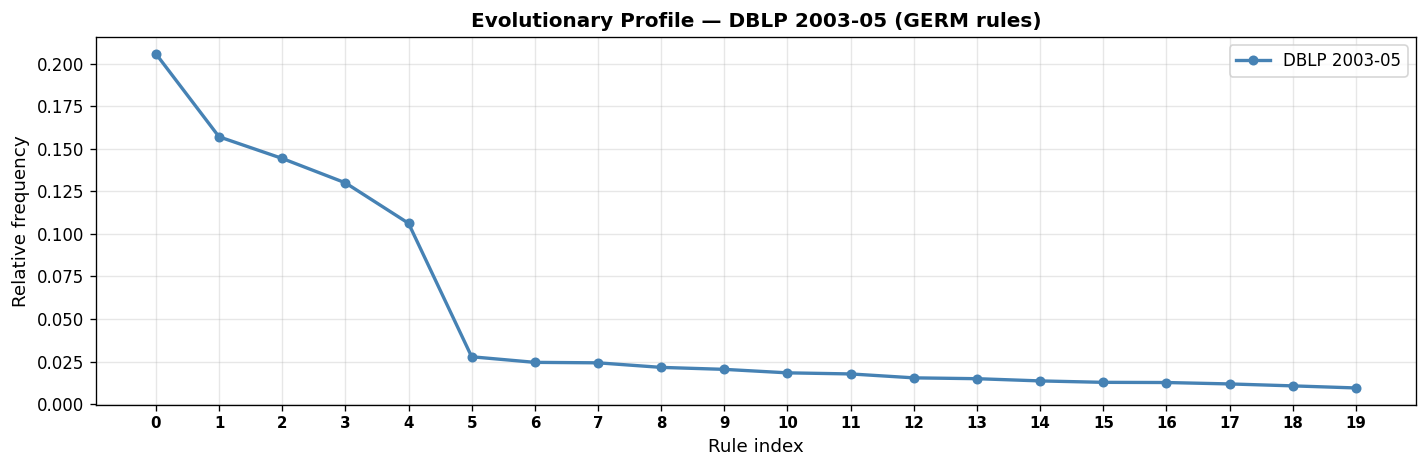

In [16]:
# Evolutionary profile: relative frequency of each rule
all_pattern_ids = list(new_support.keys())
profile = a.get_profiles(
    support_file    = new_support,
    all_patterns_id = all_pattern_ids,
    profiles_path   = str(OUT_DATA / 'dblp0305')
)

plt.figure(figsize=(12, 4))
plt.plot(profile, '.-', ms=10, lw=2, color='steelblue', label='DBLP 2003-05')
plt.xticks(range(len(all_pattern_ids)), all_pattern_ids,
           fontsize=9, fontweight='bold')
plt.xlabel("Rule index", fontsize=11)
plt.ylabel("Relative frequency", fontsize=11)
plt.title("Evolutionary Profile — DBLP 2003-05 (GERM rules)", fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig(OUT_PNG / 'dblp_evolutionary_profile.png', bbox_inches='tight')
plt.show()

---
## 7. Visualizing Individual Graph Evolution Rules

A GER consists of:
- **Precondition** (body): edges with timestamp = 0 (navy/dark colour)
- **Postcondition** (head): edges with timestamp > 0 (green colour)

The rule says: "if we observe the precondition subgraph, with high probability the postcondition edges will appear next."

Example rule edges: ((0, 1, 0), (1, 2, 0), (2, 3, 0))
  (timestamp 0 = precondition, higher = postcondition)


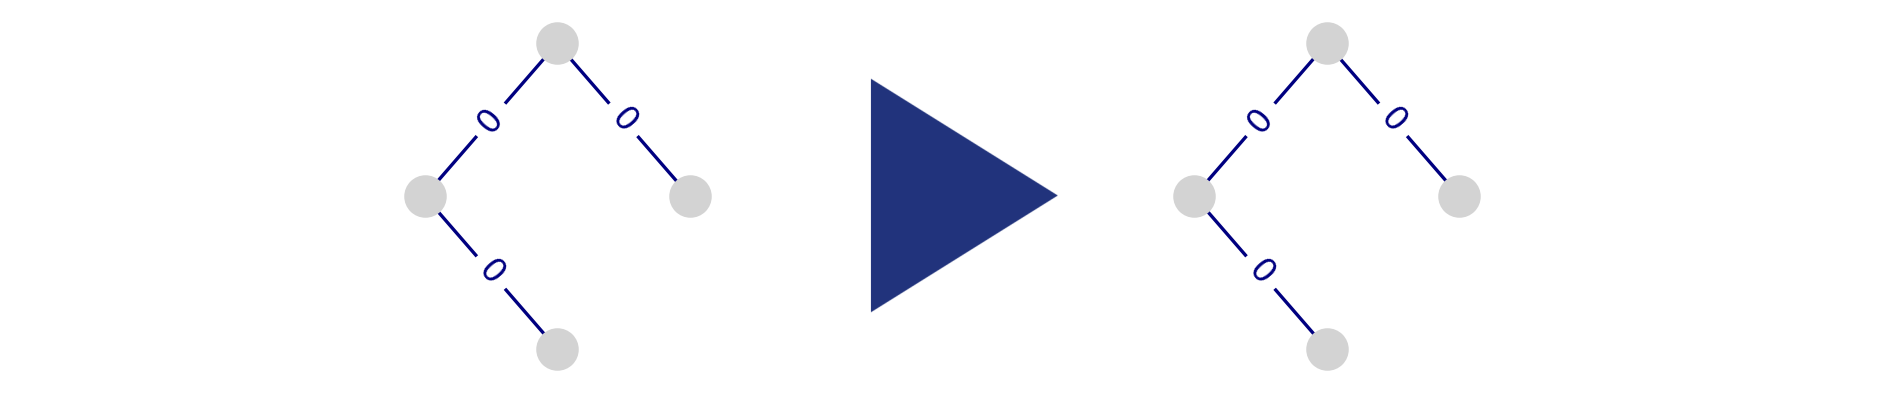

In [17]:
# Draw one rule as precondition → postcondition
example_edges = [p['edges'] for p in new_pattern_list.values()][3]
print(f"Example rule edges: {example_edges}")
print("  (timestamp 0 = precondition, higher = postcondition)")

os.chdir(EVOMINE_DIR)  # drawing.draw_rule needs imgs/ subdir
d.draw_rule('germ', list(example_edges), w_box=4)
plt.savefig(OUT_PNG / 'example_rule_germ.png', bbox_inches='tight')
plt.show()

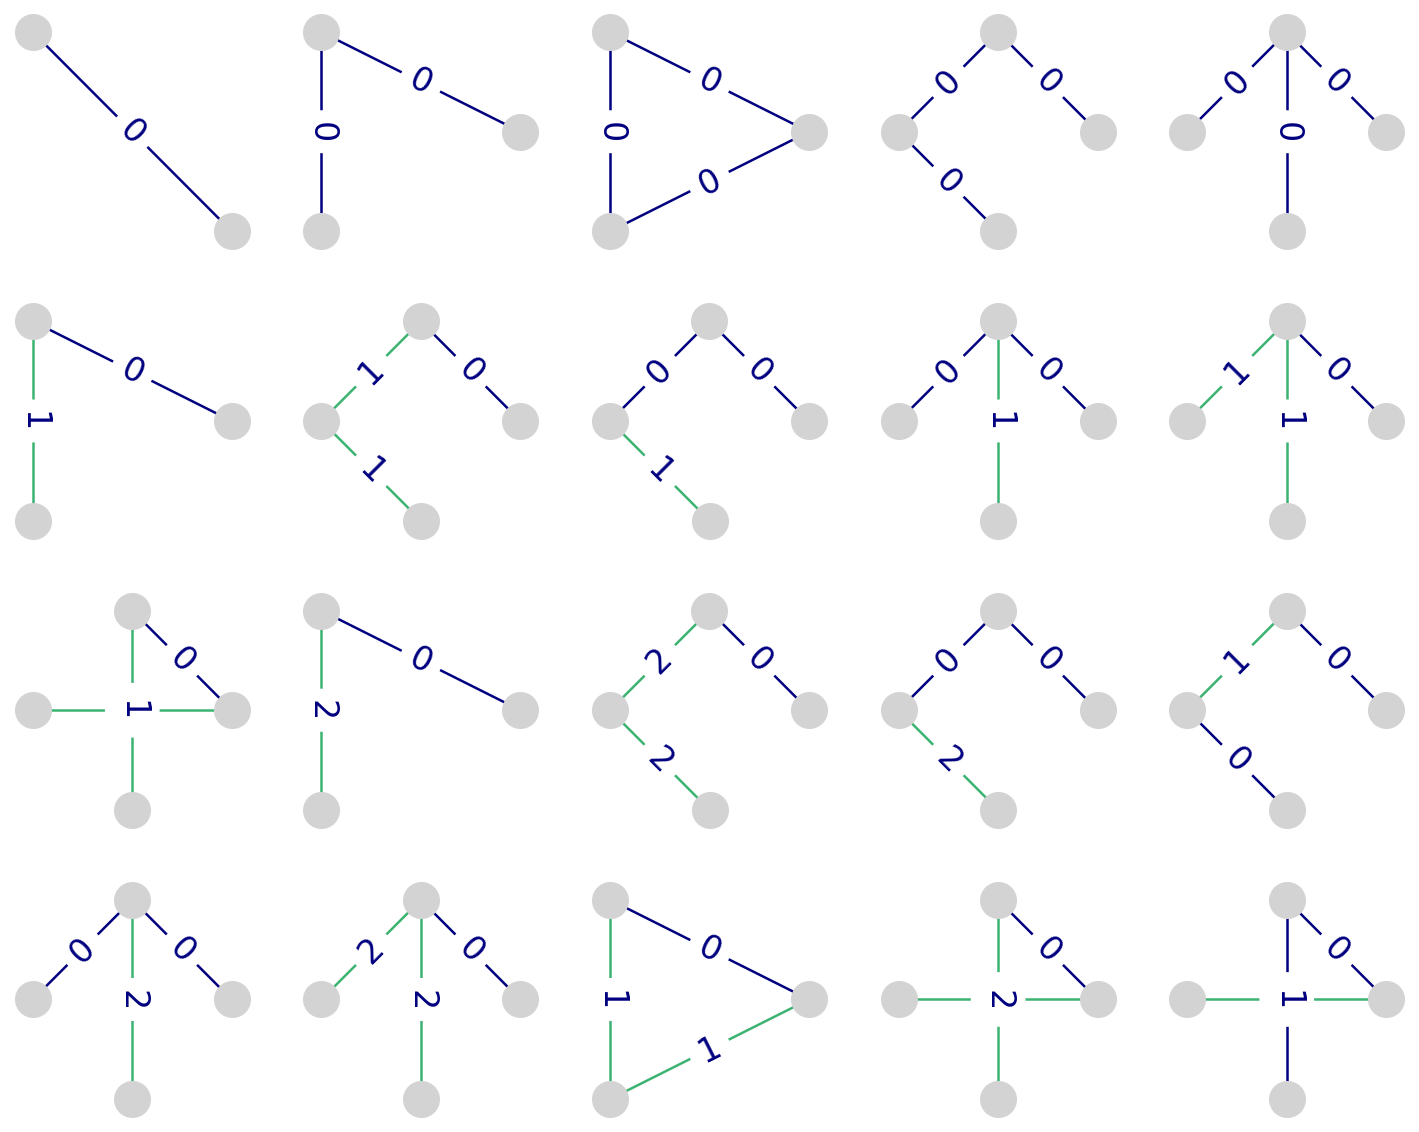

In [18]:
# Gallery of all patterns
edge_lists = {i: list(p['edges']) for i, p in new_pattern_list.items()}
d.draw_several_patterns('germ', edge_lists, columns=5, w_box=3)
plt.savefig(OUT_PNG / 'dblp_all_patterns_gallery.png', bbox_inches='tight')
plt.show()

---
## 8. T-Span Analysis

**T-span** is the maximum temporal distance (in timestamp buckets) between any two edges in a rule. It indicates how long the evolutionary pattern takes to unfold.

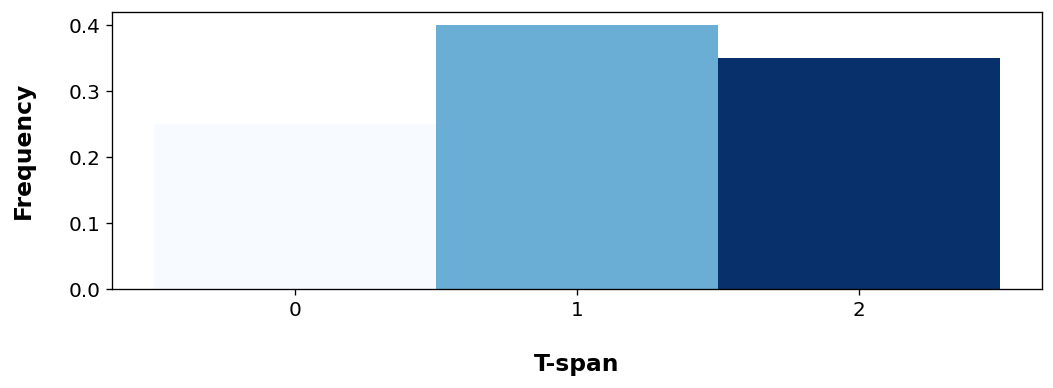

<Figure size 768x576 with 0 Axes>

T-span per pattern: {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 1, 6: 1, 7: 1, 8: 1, 9: 1, 10: 1, 11: 2, 12: 2, 13: 2, 14: 1, 15: 2, 16: 2, 17: 1, 18: 2, 19: 2}


In [19]:
spans = a.t_span_plot(
    new_pattern_list,
    cmap='Blues',
    fs=(10, 3),
    cbar_ticks_size=20,
    ticks_params={'fontsize_x': 12, 'rotation_x': 0, 'fontweight_x': 'bold',
                  'fontsize_y': 12, 'rotation_y': 0, 'fontweight_y': 'bold'},
    label_params={'xlabel': '\nT-span', 'fontsize_x': 14, 'fontweight_x': 'bold',
                  'ylabel': 'Frequency\n', 'fontsize_y': 14, 'fontweight_y': 'bold'}
)
plt.savefig(OUT_PNG / 'dblp_tspan.png', bbox_inches='tight')
plt.show()
print(f"T-span per pattern: {spans}")

---
## 9. Comparison: EvoMine/GERM vs MTM/TMC (Task 1)

| Aspect | MTM / TMC (Task 1) | EvoMine / GERM (Task 2) |
|--------|-------------------|-------------------------|
| **What they find** | Temporal motifs: small, fixed subgraph patterns | Graph Evolution Rules: how subgraphs transform |
| **Output** | Count matrix / enrichment score per motif | Ranked list of rules with support values |
| **Causality** | Observational: co-occurrence within a time window | Predictive: precondition → postcondition |
| **Graph direction** | Directed only (MTM) | Both directed and undirected |
| **Timestamp model** | Exact timestamps, sliding window δ | Discretised time buckets (before/after) |
| **Pattern structure** | Fixed k-node subgraphs | Variable size: body (t=0) + head (t>0) |
| **Support definition** | Raw count of occurrences | MIB (Minimum Image-Based) support |
| **Key parameter** | δ (time window), k (motif size) | support threshold, max head edges |
| **Use case** | Characterise network dynamics | Predict future edge formation |


In [20]:
# Summary statistics of the patterns found
print("=== DBLP 2003-05 — Pattern Summary (GERM) ===")
print(f"  Total rules found:  {len(patterns)}")
print(f"  Support range:      {min(supports):,} — {max(supports):,}")
print(f"  Median support:     {int(np.median(supports)):,}")
print(f"  Total rule weight:  {sum(supports):,}")
print()
print("Top 5 most frequent rules:")
for rank, (pid, sup) in enumerate(
        sorted(support_patterns.items(), key=lambda x: int(x[1]), reverse=True)[:5], 1):
    edges_in_rule = len(patterns[pid]['edges'])
    print(f"  #{rank}  pattern_id={pid}  support={int(sup):,}  edges={edges_in_rule}")

=== DBLP 2003-05 — Pattern Summary (GERM) ===
  Total rules found:  20
  Support range:      5,054 — 109,044
  Median support:     10,297
  Total rule weight:  529,964

Top 5 most frequent rules:
  #1  pattern_id=0  support=109,044  edges=1
  #2  pattern_id=1  support=83,197  edges=2
  #3  pattern_id=2  support=76,462  edges=3
  #4  pattern_id=3  support=68,876  edges=3
  #5  pattern_id=4  support=56,292  edges=3


---
## 10. Post-Run Analysis (when EvoMine output is available)

Once EvoMine is run on Linux (see Section 5 for commands), the output files will be saved in `output_data/`. Run the cells below to parse and visualize those results.

[CollegeMsg] Rules found: 14
Saved: /Users/inve14/Desktop/UnInve/Tirocinio/lab/task_2/output_png/CollegeMsg_profile.png


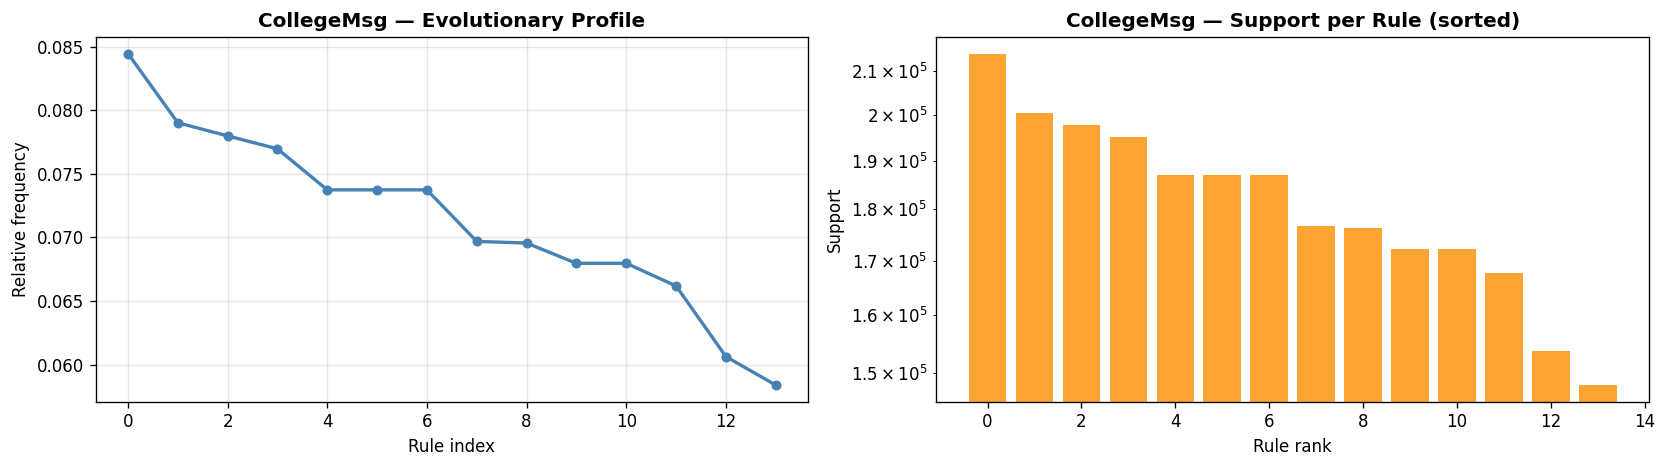

[Facebook] Rules found: 27
Saved: /Users/inve14/Desktop/UnInve/Tirocinio/lab/task_2/output_png/Facebook_profile.png


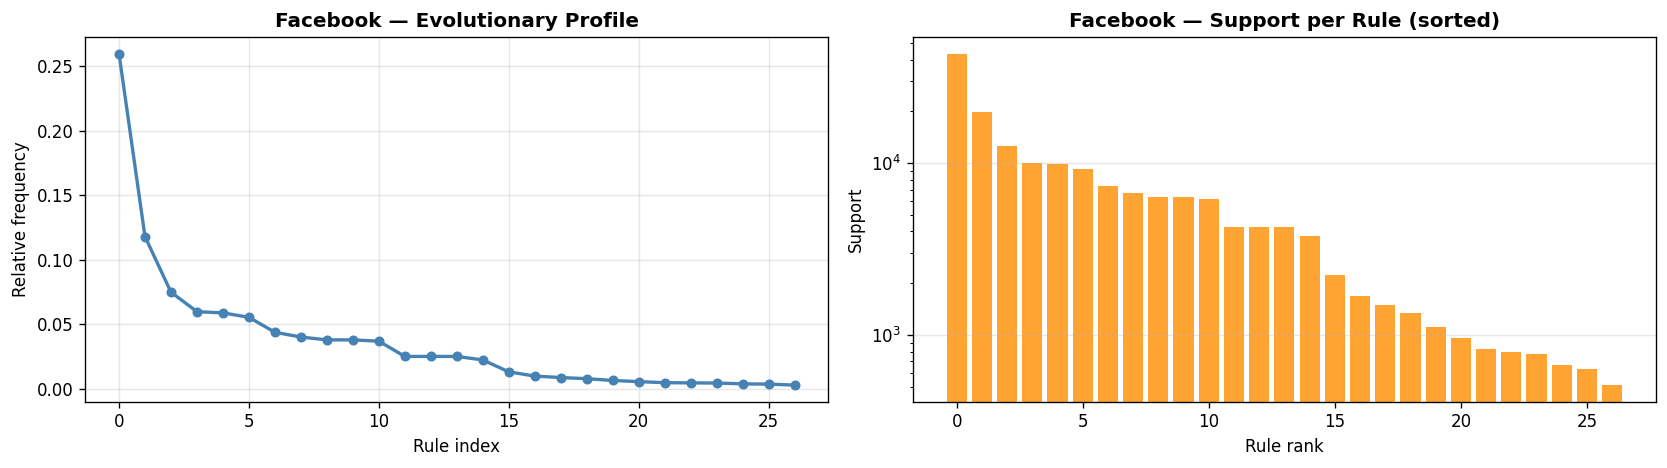

In [21]:
def analyze_ger_output(output_file, algorithm='evomine', dataset_name='dataset', out_png_dir=None):
    """
    Full pipeline: parse GER output → map pattern IDs → compute profile → plot.
    """
    output_file = Path(output_file)
    if not output_file.exists():
        print(f"File not found: {output_file}")
        return None, None, None

    info_list, patterns, support_patterns, mapping = f.from_ger_output(str(output_file))
    pattern_list, support = f.obtain_pattern_list(patterns, support_patterns, algorithm=algorithm)

    print(f"[{dataset_name}] Rules found: {len(patterns)}")

    new_pattern_list, new_support = gm.mapping_pattern_ids(
        algo              = algorithm,
        patterns          = pattern_list,
        support           = support,
        general_mapping   = dict(),
        mapped_patterns_path = str(EVOMINE_DIR / 'processed-outputs' / f'{dataset_name}_mapped'),
        directed          = True
    )

    all_ids = list(new_support.keys())
    profile = a.get_profiles(new_support, all_ids)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax = axes[0]
    ax.plot(profile, '.-', ms=10, lw=2, color='steelblue')
    ax.set_title(f'{dataset_name} — Evolutionary Profile', fontsize=12, fontweight='bold')
    ax.set_xlabel('Rule index')
    ax.set_ylabel('Relative frequency')
    ax.grid(alpha=0.3)

    ax = axes[1]
    supports_vals = list(new_support.values())
    ax.bar(range(len(supports_vals)),
           sorted(supports_vals, reverse=True),
           color='darkorange', alpha=0.8)
    ax.set_title(f'{dataset_name} — Support per Rule (sorted)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Rule rank')
    ax.set_ylabel('Support')
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    if out_png_dir:
        save_path = Path(out_png_dir) / f'{dataset_name}_profile.png'
        plt.savefig(save_path, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()

    return new_pattern_list, new_support, profile


# CollegeMsg — support=20000 (support=1000 troppo lento su macOS ARM64 via Docker)
college_patterns, college_support, college_profile = analyze_ger_output(
    output_file  = OUT_DATA / 'college_evomine_20000_3.txt',
    algorithm    = 'evomine',
    dataset_name = 'CollegeMsg',
    out_png_dir  = OUT_PNG
)

# Facebook Wall (campione 10k) — support=500
facebook_patterns, facebook_support, facebook_profile = analyze_ger_output(
    output_file  = OUT_DATA / 'facebook_evomine_500_3.txt',
    algorithm    = 'evomine',
    dataset_name = 'Facebook',
    out_png_dir  = OUT_PNG
)

---
## 11. Heatmap Comparison (requires both datasets run)

When both CollegeMsg and Facebook outputs are available, compare their evolutionary profiles side by side using a heatmap.

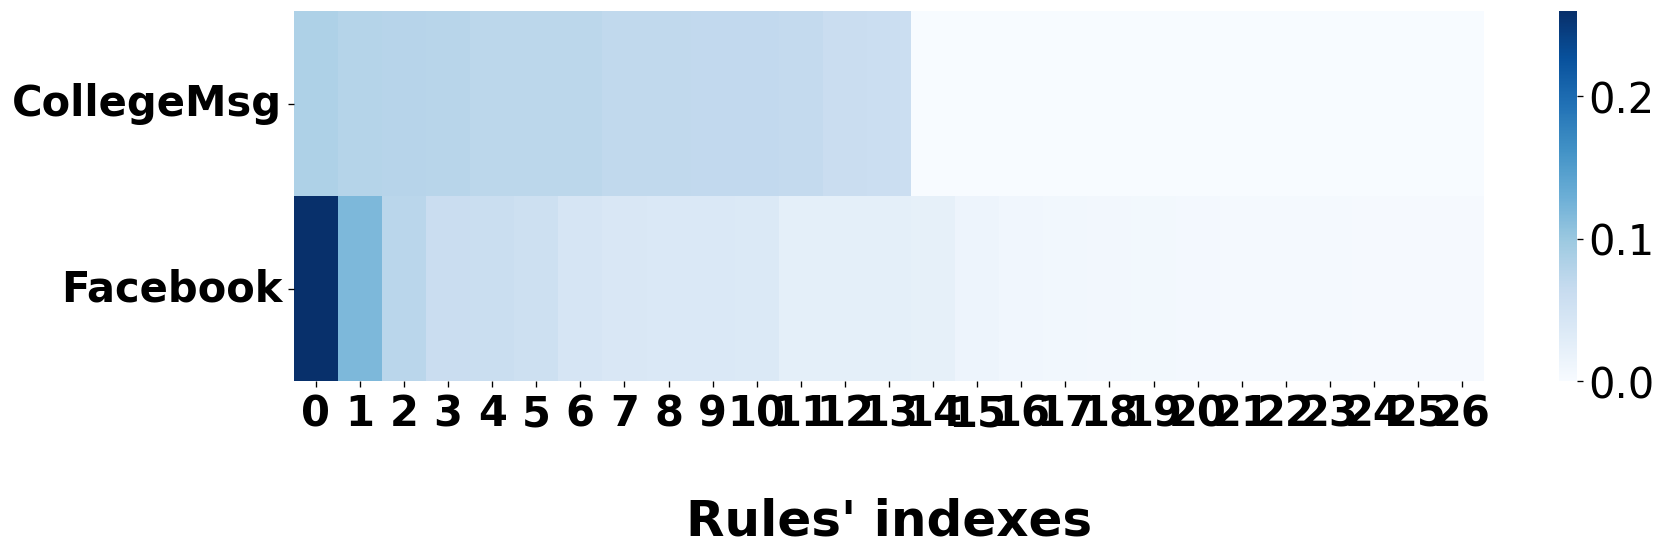

In [22]:
if college_profile is not None and facebook_profile is not None:
    # Align profiles to the same rule set (pad with zeros if needed)
    max_len = max(len(college_profile), len(facebook_profile))
    c_padded = list(college_profile)  + [0] * (max_len - len(college_profile))
    f_padded = list(facebook_profile) + [0] * (max_len - len(facebook_profile))

    a.plot_heatmap(
        profiles      = [c_padded, f_padded],
        ger_ids       = list(range(max_len)),
        single_profile = False,
        cmap          = 'Blues',
        fs            = (16, 4),
        xticks        = ['CollegeMsg', 'Facebook'],
        vertical_rules = False,
        savefig       = str(OUT_PNG / 'comparison_heatmap.png')
    )
else:
    print("Heatmap comparison requires both EvoMine outputs.")
    print("Run EvoMine on Linux first, then re-execute this cell.")

---
## 12. Summary and Next Steps

### What we accomplished
1. Explored the GERANIO/EvoMine codebase and understood its pipeline.
2. Loaded and inspected both datasets (CollegeMsg: 59,835 edges; Facebook Wall: 876,993 edges).
3. Converted both datasets to GER input format (`t # 0 / v / e` lines).
4. Demonstrated EvoMine command-line usage and parameter meanings.
5. Parsed and visualized the pre-computed DBLP 2003-05 GERM output (20 rules).
6. Plotted evolutionary profiles, support distributions, pattern galleries, and t-span analysis.

### Blocker: binary incompatibility
The EvoMine and GERM binaries are **Linux x86-64 ELF** and cannot run on **macOS ARM64**.

### Resolution options
- **Docker** (recommended): `docker run --rm -v $(pwd):/data ubuntu:22.04 /data/algorithms/evomine ...`
- **Remote Linux server**: Copy the `EvoMine/` directory, run the binary, copy back output files.
- **Rosetta 2 + compatibility layer**: Experimental and complex on macOS.

### Recommended parameters for these datasets
| Dataset | Support | Max edges | Mode |
|---------|---------|-----------|------|
| CollegeMsg (full, 59k) | 1000 | 3 | directed |
| Facebook Wall (sample 10k) | 200 | 3 | directed |
| Facebook Wall (full, 877k) | 5000 | 3 | directed |